In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist
from PIL import Image

# 載入MNIST數據集並準備數據
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784) / 255.0
x_test = x_test.reshape(10000, 784) / 255.0
#輸出有10 個類別
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 建立模型
model = Sequential([
    Dense(100, input_dim=784, activation='relu'),
    Dense(100, activation='relu'),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
#784*100+100 + 100*100+100 + 100*100+100 + 10*100+10 = 99710 weights
#分類問題通常最後都用softmax

# 編譯模型
model.compile(optimizer=SGD(learning_rate=0.09), loss='mean_squared_error', metrics=['accuracy'])

# 訓練模型
model.fit(x_train, y_train, batch_size=100, epochs=20)
#batchsize=100  一次100，100......餵給神經網路
#分600次訓練(修正600次權重)  全部跑過一次 1 epoch

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2189 - loss: 0.0887
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4816 - loss: 0.0748
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7634 - loss: 0.0406
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8531 - loss: 0.0243
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8817 - loss: 0.0190
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8972 - loss: 0.0164
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9032 - loss: 0.0152
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9089 - loss: 0.0142
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9126 - loss: 0.0136
Epoch 10/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9180 - loss: 0.0128
Epoch 11/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9228 - loss: 0.0122
Epoch 12/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/s

Saving 3.png to 3.png


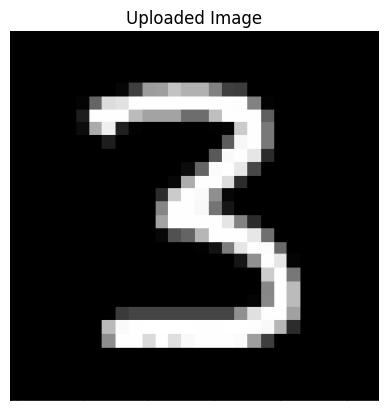

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Probability of 0: 0.00
Probability of 1: 0.00
Probability of 2: 0.00
Probability of 3: 1.00
Probability of 4: 0.00
Probability of 5: 0.00
Probability of 6: 0.00
Probability of 7: 0.00
Probability of 8: 0.00
Probability of 9: 0.00


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import io
from google.colab import files
import matplotlib.pyplot as plt



def preprocess_image(image):
    """將上傳的圖片轉換為模型需要的格式"""
    # 轉換為灰階
    image = image.convert('L')
    # 調整大小為28x28
    image = image.resize((28, 28))
    # 轉換為numpy數組
    image_array = np.array(image)
    # 將數據標準化到0-1範圍
    image_array = image_array / 255.0
    # 重塑為模型輸入的形狀
    image_array = image_array.reshape(1, 784)
    return image_array

def predict(image):
    """使用模型進行預測"""
    # 預處理圖片
    image_array = preprocess_image(image)
    # 使用模型進行預測
    predictions = model.predict(image_array)
    # 返回每個數字的機率
    return predictions[0]

# 上傳圖片
uploaded = files.upload()

# 讀取上傳的圖片
for filename in uploaded.keys():
    # 打開圖片
    image = Image.open(io.BytesIO(uploaded[filename]))

    # 顯示圖片
    plt.imshow(image, cmap='gray')
    plt.title('Uploaded Image')
    plt.axis('off')
    plt.show()

    # 進行預測
    probabilities = predict(image)

    # 顯示預測結果
    for i, prob in enumerate(probabilities):
        print(f'Probability of {i}: {prob:.2f}')
